### Analysis of World Fuel Prices as at 4-April-2026

#### from Kaggle, https://www.kaggle.com/datasets/zkskhurram/world-vs-asia-fuel-prices/data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../Project_2/data_kaggle/asia_fuel_prices_detailed.csv")
print(df.head())

      country  sub_region iso3  gasoline_usd_per_liter  diesel_usd_per_liter  \
0    Pakistan  South Asia  PAK                    1.64                  1.86   
1       India  South Asia  IND                    1.11                  1.03   
2  Bangladesh  South Asia  BGD                    1.07                  0.93   
3   Sri Lanka  South Asia  LKA                    1.34                  1.19   
4       Nepal  South Asia  NPL                    1.34                  1.21   

   lpg_usd_per_kg  avg_monthly_income_usd  fuel_affordability_index  \
0            1.25                     180                       3.7   
1            1.08                     280                       8.4   
2            0.98                     160                       5.0   
3            1.18                     210                       5.2   
4            1.28                     120                       3.0   

   oil_import_dependency_pct  refinery_capacity_kbpd  ev_adoption_pct  \
0                  

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    22 non-null     object 
 1   sub_region                 22 non-null     object 
 2   iso3                       22 non-null     object 
 3   gasoline_usd_per_liter     22 non-null     float64
 4   diesel_usd_per_liter       22 non-null     float64
 5   lpg_usd_per_kg             22 non-null     float64
 6   avg_monthly_income_usd     22 non-null     int64  
 7   fuel_affordability_index   22 non-null     float64
 8   oil_import_dependency_pct  22 non-null     int64  
 9   refinery_capacity_kbpd     22 non-null     int64  
 10  ev_adoption_pct            22 non-null     float64
 11  fuel_subsidy_active        22 non-null     bool   
 12  subsidy_cost_bn_usd        22 non-null     float64
 13  co2_transport_mt           22 non-null     float64
 

In [14]:
df.describe(include='all')

,country,sub_region,iso3,gasoline_usd_per_liter,diesel_usd_per_liter,lpg_usd_per_kg,avg_monthly_income_usd,fuel_affordability_index,oil_import_dependency_pct,refinery_capacity_kbpd,ev_adoption_pct,fuel_subsidy_active,subsidy_cost_bn_usd,co2_transport_mt,price_date,gasoline_pct_daily_wage
count,22,22,22,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22,22.000000,22.000000,22,22.000000
unique,22,3,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,1,NaN
top,Pakistan,Southeast Asia,PAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,2026-04-04,NaN
freq,1,11,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,22,NaN
mean,NaN,NaN,NaN,1.178636,1.093182,0.954091,931.818182,30.577273,81.363636,1695.818182,2.163636,NaN,3.090909,95.731818,NaN,14.577273
std,NaN,NaN,NaN,0.427265,0.360137,0.252373,1279.704714,44.764430,27.830346,3871.025638,3.199337,NaN,5.140216,214.338763,NaN,13.043770
min,NaN,NaN,NaN,0.390000,0.230000,0.300000,60.000000,2.300000,0.000000,0.000000,0.000000,NaN,0.000000,0.400000,NaN,0.500000
25%,NaN,NaN,NaN,1.062500,0.935000,0.827500,165.000000,4.175000,64.500000,8.250000,0.100000,NaN,0.000000,4.425000,NaN,2.250000
50%,NaN,NaN,NaN,1.195000,1.070000,0.965000,295.000000,8.500000,98.500000,320.000000,0.450000,NaN,0.000000,26.250000,NaN,11.800000
75%,NaN,NaN,NaN,1.335000,1.185000,1.132500,925.000000,50.900000,100.000000,1305.000000,3.325000,NaN,4.775000,73.250000,NaN,23.900000


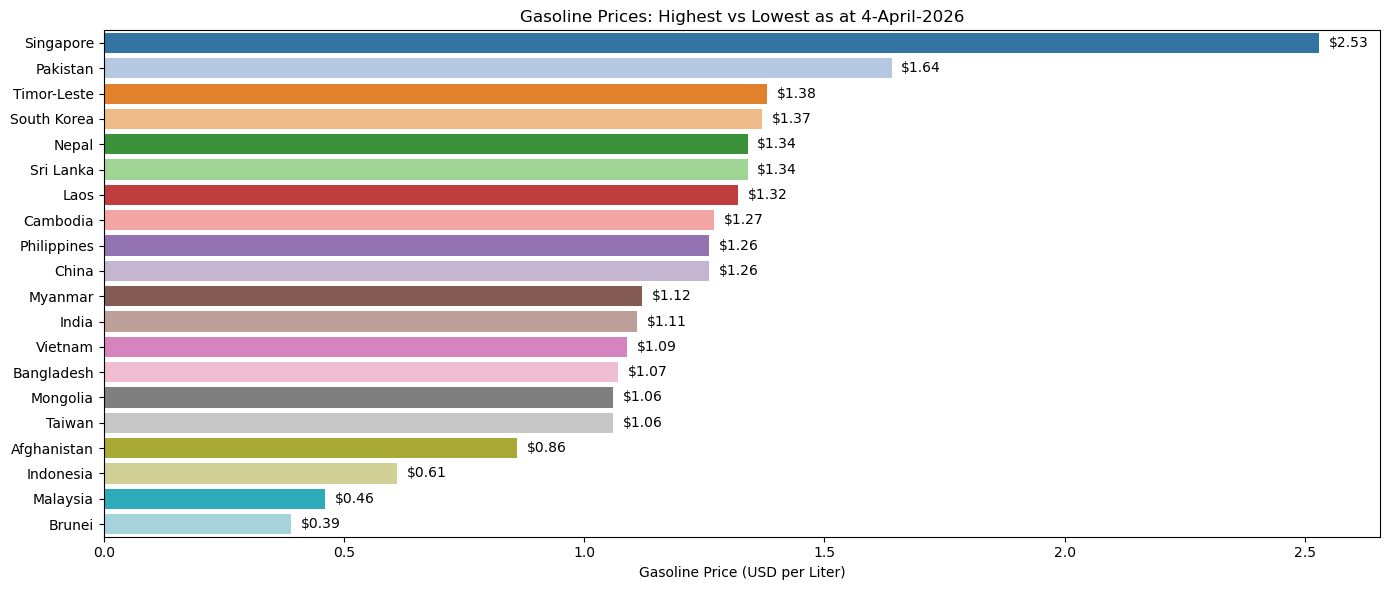

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sort gasoline price from lowest to highest
gas_price = (
    df[["country", "gasoline_usd_per_liter"]]
    .sort_values("gasoline_usd_per_liter", ascending=False)
)

# Lowest 10 + highest 10
lowest = gas_price.tail(10)
highest = gas_price.head(10)

price_chart = pd.concat([highest, lowest])

plt.figure(figsize=(14, 6))

# Different color for each bar
colors = sns.color_palette("tab20", len(price_chart))

sns.barplot(
    data=price_chart,
    x="gasoline_usd_per_liter",
    y="country",
    hue="country",
    palette=colors,
    legend=False
)

plt.xlabel("Gasoline Price (USD per Liter)")
plt.ylabel("")
plt.title("Gasoline Prices: Highest vs Lowest as at 4-April-2026")

# Add value labels
for i, value in enumerate(price_chart["gasoline_usd_per_liter"]):
    plt.text(
        value + 0.02,
        i,
        f"${value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

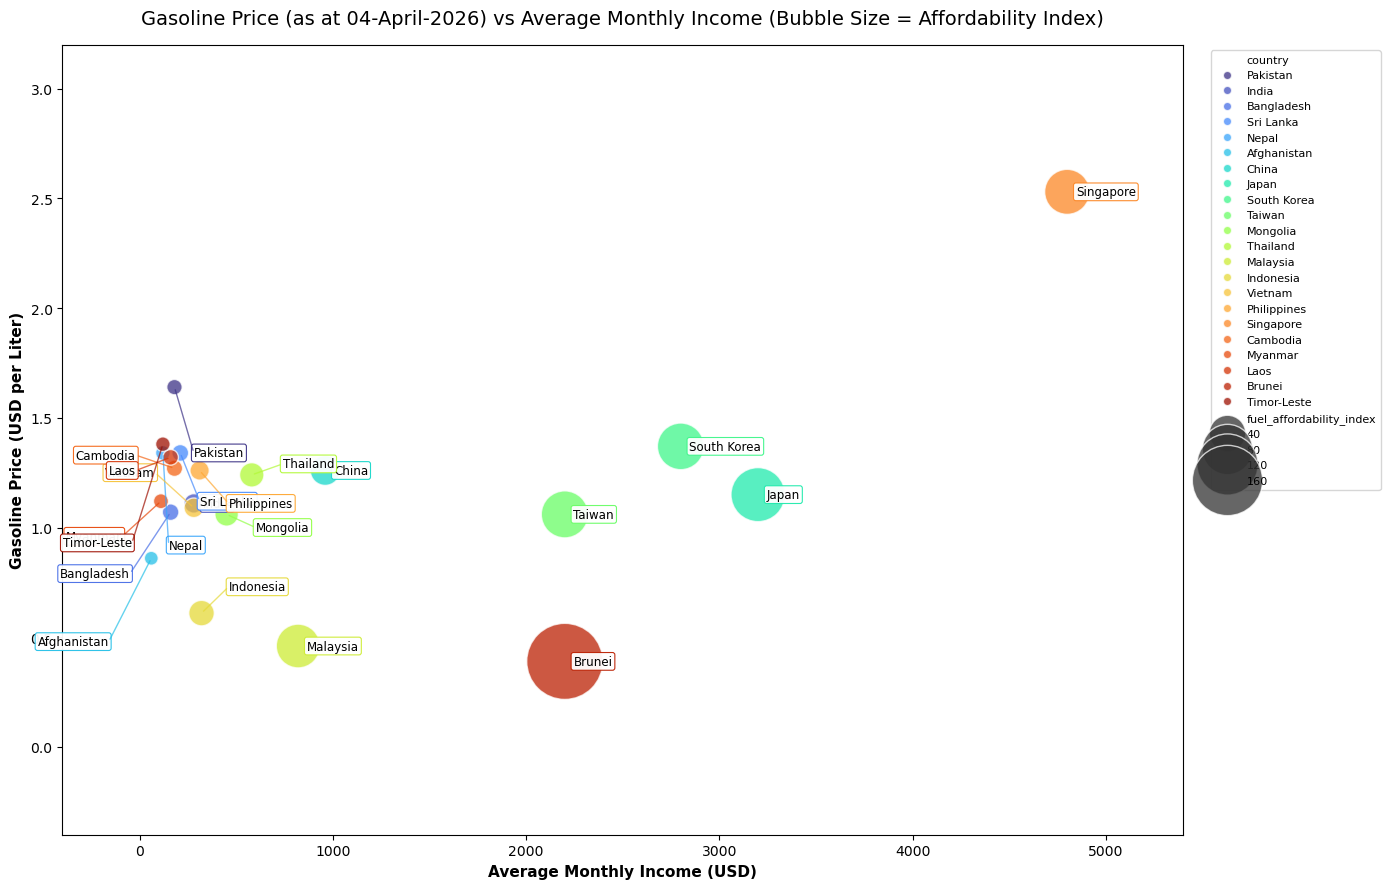

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 9))

# 1. High-variety palette to keep every country visually distinct
country_palette = "turbo" 

# 2. Re-mapped configurations with ENHANCED bubble scaling
ax = sns.scatterplot(
    data=df,
    x="avg_monthly_income_usd",
    y="gasoline_usd_per_liter",        
    size="fuel_affordability_index",   
    hue="country",                 
    palette=country_palette,       
    sizes=(100, 3000),                 # <--- Increased the upper bound to 3000 for presentation-ready impact
    alpha=0.75,
    edgecolor="white",
    linewidth=1
)

# 3. Manual layout shifts (X in dollars, Y in decimals) for crowded areas
manual_offsets = {
    "Indonesia": (140, 0.12),
    "Thailand": (160, 0.05),
    "Mongolia": (150, -0.06),
    "Philippines": (150, -0.15),
    "Vietnam": (-200, 0.16),
    "Cambodia": (-200, 0.06),
    "Laos": (-180, -0.06),
    "Myanmar": (-200, -0.16),
    "Sri Lanka": (100, -0.22),
    "Pakistan": (100, -0.30),
    "Bangladesh": (-210, -0.28),
    "Afghanistan": (-220, -0.38),
    "Nepal": (30, -0.42),
    "Timor-Leste": (-160, -0.45)
}

# 4. Extract the color array directly from the collection layer
facecolors = ax.collections[0].get_facecolors()
country_to_color = dict(zip(df["country"], facecolors))

# 5. Plot labels and matching color leader lines
for _, row in df.iterrows():
    country = row["country"]
    x_orig = row["avg_monthly_income_usd"]
    y_orig = row["gasoline_usd_per_liter"] 
    
    # Grab the individual color allocated to this specific country
    unique_color = country_to_color.get(country, "dimgray")
    
    x_offset, y_offset = manual_offsets.get(country, (45, 0.0))
    
    label_x = x_orig + x_offset
    label_y = y_orig + y_offset
    
    if country in manual_offsets:
        ha_align = "right" if x_offset < 0 else "left"
    else:
        ha_align = "left"

    # Print the country text label with a border matching its unique bubble
    ax.text(
        label_x, 
        label_y, 
        country, 
        fontsize=8.5, 
        ha=ha_align, 
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.2", 
            fc="white", 
            ec=unique_color,       
            lw=0.8, 
            alpha=0.95
        )
    )
    
    # If the label was manually shifted, draw a matching connection line
    if country in manual_offsets:
        ax.annotate(
            "",
            xy=(x_orig, y_orig),         
            xytext=(label_x, label_y),   
            arrowprops=dict(
                arrowstyle="-",          
                color=unique_color,      
                lw=1.0, 
                alpha=0.7,
                connectionstyle="arc3"   
            )
        )

# Styling and Scale Boundaries
plt.xlabel("Average Monthly Income (USD)", fontsize=11, fontweight="bold")
plt.ylabel("Gasoline Price (USD per Liter)", fontsize=11, fontweight="bold")
plt.title("Gasoline Price (as at 04-April-2026) vs Average Monthly Income (Bubble Size = Affordability Index)", fontsize=14, pad=15)

# Expand bounds slightly to accommodate the massive new bubble radiuses
ax.set_xlim(-400, 5400)
ax.set_ylim(-0.4, 3.2) 

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=1
)

plt.tight_layout()
plt.show()

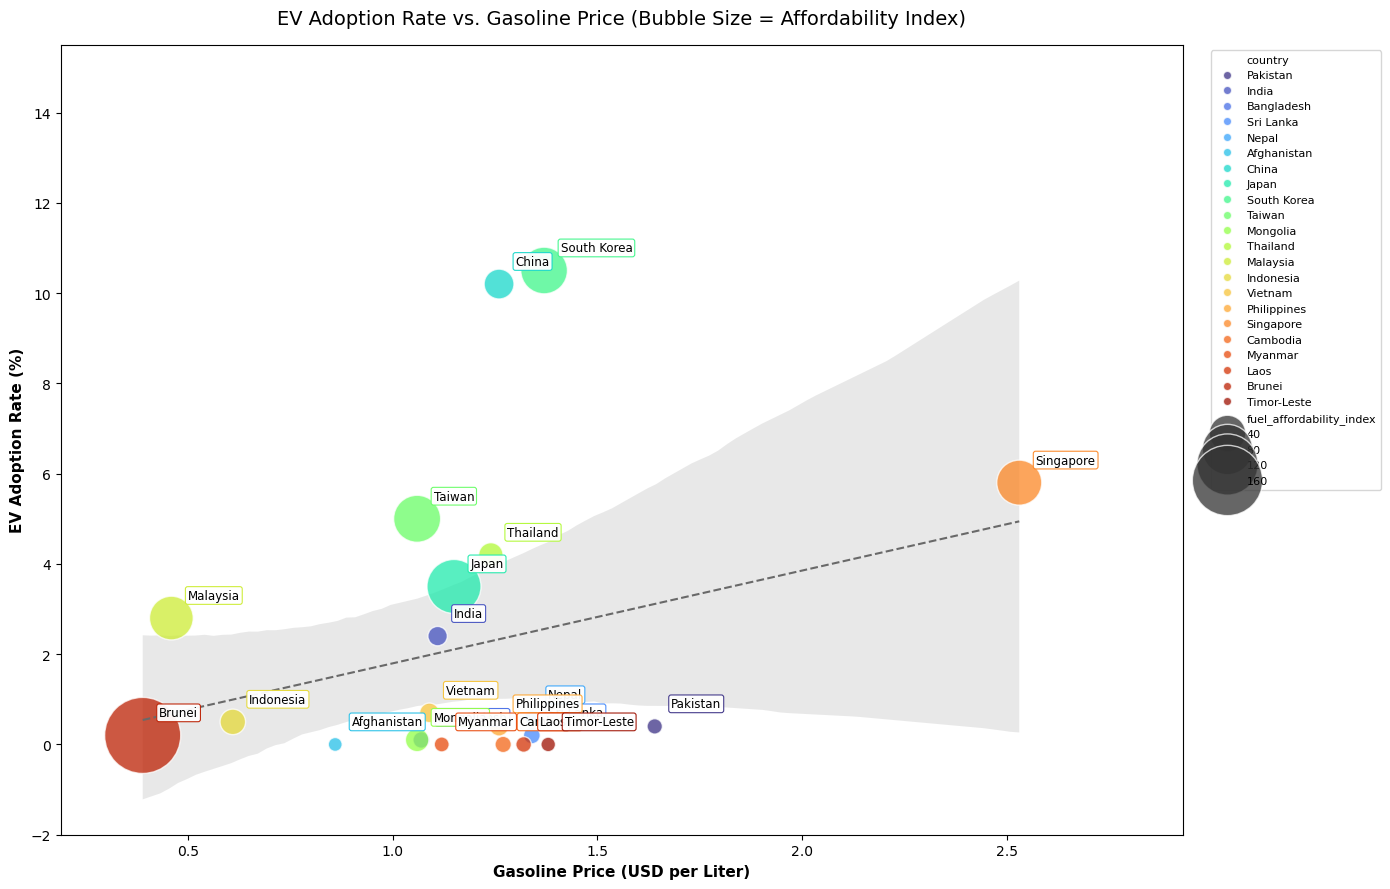

In [56]:
plt.figure(figsize=(14, 9))

# 1. High-variety palette to keep every country visually distinct
country_palette = "turbo" 

# 2. Draw the linear regression line first so it sits cleanly beneath the data points
# sns.regplot calculates and plots a linear trend line with a 95% confidence interval band
sns.regplot(
    data=df,
    x="gasoline_usd_per_liter",
    y="ev_adoption_pct",
    scatter=False,               # Do not draw default dots; we will style those with scatterplot below
    color="dimgray",             # Subtle gray line color
    line_kws={"linewidth": 1.5, "linestyle": "--"}, # Dashed line style
    ci=95                        # Shows the shaded statistical confidence interval area
)

# 3. Generate the primary bubble scatterplot configuration
ax = sns.scatterplot(
    data=df,
    x="gasoline_usd_per_liter",        # <--- Re-plotted X-axis to Gasoline Price
    y="ev_adoption_pct",              # <--- Re-plotted Y-axis to EV Adoption Rate
    size="fuel_affordability_index",   # <--- Keeping the presentation bubble sizing
    hue="country",                 
    palette=country_palette,       
    sizes=(100, 3000),                 
    alpha=0.75,
    edgecolor="white",
    linewidth=1
)

# 4. Extract the dynamically generated country color mappings
facecolors = ax.collections[1].get_facecolors() # Index 1 extracts from the scatter layer rather than the regplot layer
country_to_color = dict(zip(df["country"], facecolors))

# 5. Automatically label all countries with a uniform proportional layout offset
for _, row in df.iterrows():
    country = row["country"]
    x_orig = row["gasoline_usd_per_liter"]
    y_orig = row["ev_adoption_pct"]
    
    unique_color = country_to_color.get(country, "dimgray")
    
    # Apply small percentage offsets relative to the axis parameters to lift the labels off the bubbles
    label_x = x_orig + 0.04  
    label_y = y_orig + 0.5   

    # Print the country text label with a matching color border
    ax.text(
        label_x, 
        label_y, 
        country, 
        fontsize=8.5, 
        ha="left", 
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.2", 
            fc="white", 
            ec=unique_color,       
            lw=0.8, 
            alpha=0.95
        )
    )

# Axis Labels, Title, and Boundary Buffers
plt.xlabel("Gasoline Price (USD per Liter)", fontsize=11, fontweight="bold")
plt.ylabel("EV Adoption Rate (%)", fontsize=11, fontweight="bold")
plt.title("EV Adoption Rate vs. Gasoline Price (Bubble Size = Affordability Index)", fontsize=14, pad=15)

# Expand margins slightly so text on the absolute borders doesn't clip
ax.set_xlim(df["gasoline_usd_per_liter"].min() - 0.2, df["gasoline_usd_per_liter"].max() + 0.4)
ax.set_ylim(df["ev_adoption_pct"].min() - 2.0, df["ev_adoption_pct"].max() + 5.0) 

# Configure the sidebar legend panel cleanly
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=1
)

plt.tight_layout()
plt.show()
